[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/27%20-%20Image%20Filtering%20via%20Convolution/Image_Filtering_via_Convolution.ipynb)

# Overview

Images are large grids of color values. Techniques have been developed over many years with the intention of extracting information from images. Here we look at one of the most common and most basic techniques, filtering via convolution.

### An Image
![Grid](https://www.dropbox.com/s/fhq8j6oo828u03r/image%20grid.png?raw=1)


### A Filter
![Filter](https://www.dropbox.com/s/kv2jl1s2yw46xvs/image%20filter.png?raw=1)

### Convolution

Many image processing techniques depend on this basic building block: **convolution**. 

Image convolution involves laying the filter "on top" of the image and computing the sum of the products of the overlapping values. The resulting value is stored in a new image. The filter (or mask) is moved by one (or more) pixel(s), and the process is repeated across the entire image.

$C_{i,j} = \sum_{F_{x,y}}{ I_{i-x,j-y}F_{x,y}}$

# Convolution in action

Image: https://www.dropbox.com/s/14dbm1onz9wx2r3/all_the_things.png?raw=1

In [0]:
!pip install imageio

    100% |████████████████████████████████| 3.3MB 7.3MB/s 
  Running setup.py bdist_wheel for imageio ... - \ | / done
  Stored in directory: /root/.cache/pip/wheels/e0/43/31/605de9372ceaf657f152d3d5e82f42cf265d81db8bbe63cde1
Successfully built imageio


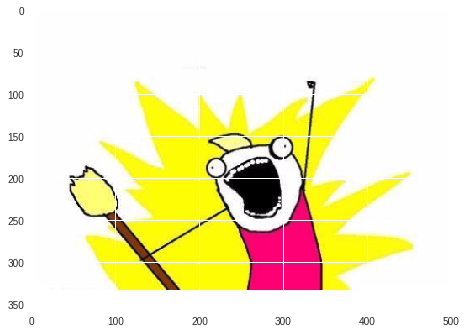

In [0]:
import imageio
import matplotlib.pyplot as plt

I = imageio.imread('https://www.dropbox.com/s/14dbm1onz9wx2r3/all_the_things.png?raw=1')
plt.imshow(I);

Convert I to grayscale, so it will be MxNx1 instead of MxNx4

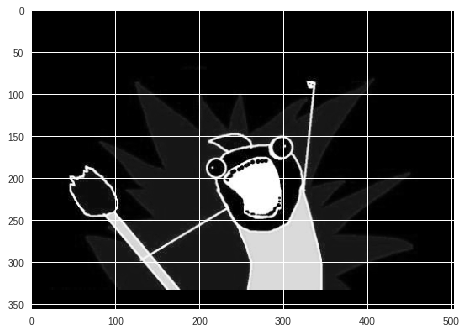

In [0]:
from skimage import color
I_g = color.rgb2gray(I)
plt.imshow(I_g);

Convolve

(356, 503)
(5, 5)


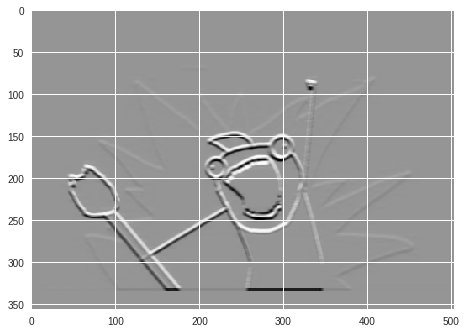

In [0]:
import numpy as np
import scipy.ndimage as nd

F = np.array([[1, 1, 1, 1, 1],
              [0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0],
              [-1, -1, -1, -1, -1]])

print(I_g.shape)
print(F.shape)
C = nd.convolve(I_g, F)
plt.imshow(C);

To not have a negative grey-scaled image (Note the 1st greyscale image `I_g`)

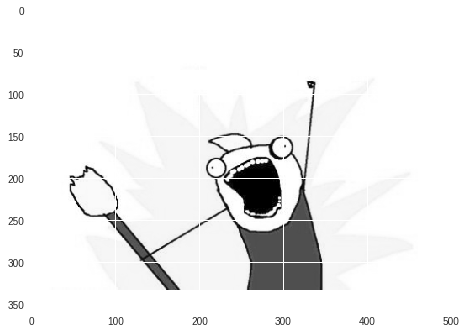

In [0]:
from skimage.exposure import rescale_intensity
I_g = rescale_intensity(1-color.rgb2gray(I))
plt.imshow(I_g);

(356, 503)
(5, 5)


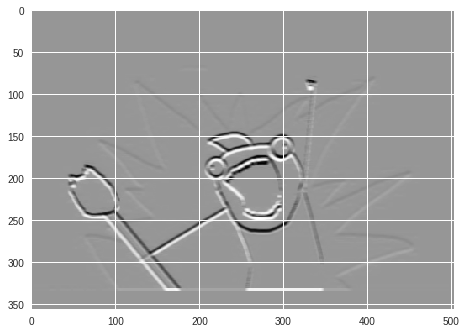

In [0]:
print(I_g.shape)
print(F.shape)
C = nd.convolve(I_g,F)
plt.imshow(C);

The above convolution is a form of "edge detection", responding most strongly where the brightness of the image changes suddenly.

---

# Using OpenCV

### Canny Edge Detection

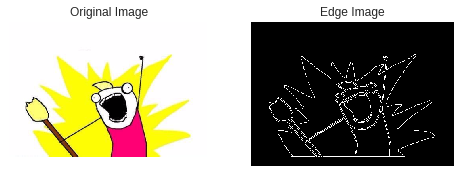

In [0]:
import cv2

edges = cv2.Canny(I, 100, 300)

plt.subplot(121),plt.imshow(I,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])

plt.show();

# Manual Implementation

Note the convolution equation

$C_{i,j} = \sum_{F_{x,y}}{ I_{i-x,j-y}F_{x,y}}$

All we need to do is iterate over $i,j$ to track across the image $I$, then for each pixel in $I$, iterate over $x,y$ and compute the sum of the product of each filter value with the image value at that $i,j$ coordinate.

### Edge cases

What will we do when the mask is along the edges of the image? We can either wrap the pixel values around, or call the function for $C_{i,j}$ undefined at that coordinate and set the value to $0$.

### Centered filter or $(0,0)$ aligned filter?

Think of the filter as being centered on each image coordinate value, so that $C_{i,j}$ and $F_{width(F)/2,height(F)/2}$ overlap during convolution. How would we modify the convolution equation to handle this case?

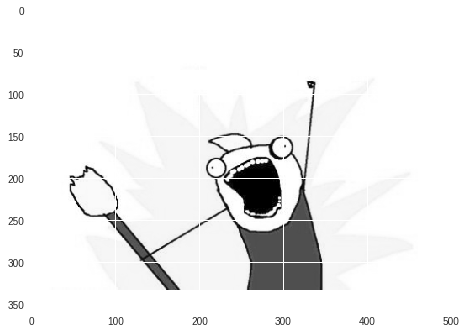

In [0]:
plt.imshow(I_g);

In [0]:
def apply_convolution_2d(I, F):
  C = np.zeros_like(I) # assign 0 to edges
  for i in np.arange(F.shape[0]-1, I.shape[0]):
    for j in np.arange(F.shape[1]-1, I.shape[1]):
      for x in range(F.shape[0]):
        for y in range(F.shape[1]):
          C[i, j] += I[i-x, j-y] * F[x, y]
  return C

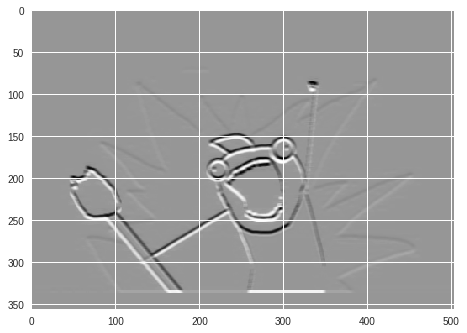

In [0]:
C = apply_convolution_2d(I_g, F)
plt.imshow(C);

The above was not a Centered Filter or a $(0, 0)$ aligned filter – the 1st convolution went to $(width(F), height(F))$ and the last convolution went to $(width(C), height(C))$

### Centered Filter

$C_{i - width(F)/2, j - height(F)/2} = \sum_{F_{x,y}}{ I_{i-x,j-y}F_{x,y}}$

In [0]:
def apply_centered_convolution_2d(I, F):
  C = np.zeros_like(I) # assign 0 to edges
  for i in np.arange(F.shape[0]-1, I.shape[0]):
    for j in np.arange(F.shape[1]-1, I.shape[1]):
      for x in range(F.shape[0]):
        for y in range(F.shape[1]):
          C[i-int(F.shape[0]/2), j-int(F.shape[1]/2)] += I[i-x, j-y] * F[x, y]
  return C

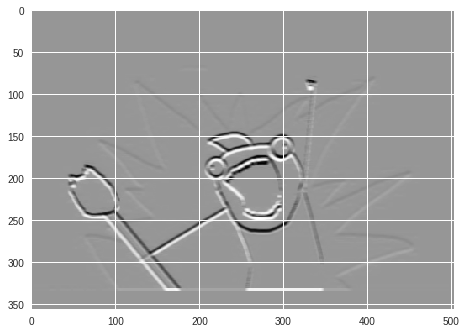

In [0]:
C = apply_centered_convolution_2d(I_g, F)
plt.imshow(C);

### $(0, 0)$ aligned filter

$C_{i - width(F), j - height(F)} = \sum_{F_{x,y}}{ I_{i-x,j-y}F_{x,y}}$

In [0]:
def apply_topleft_convolution_2d(I, F):
  C = np.zeros_like(I) # assign 0 to edges
  for i in np.arange(F.shape[0]-1, I.shape[0]):
    for j in np.arange(F.shape[1]-1, I.shape[1]):
      for x in range(F.shape[0]):
        for y in range(F.shape[1]):
          C[i-int(F.shape[0]), j-int(F.shape[1])] += I[i-x, j-y] * F[x, y]
  return C

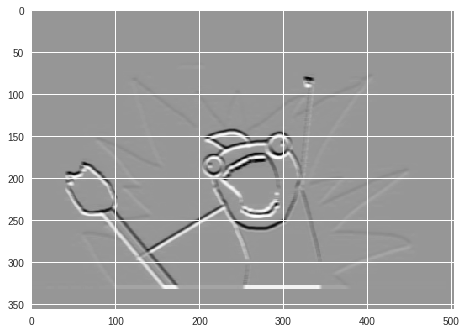

In [0]:
C = apply_topleft_convolution_2d(I_g, F)
plt.imshow(C);